<a href="https://colab.research.google.com/github/balakganesh2k3/Intro-to-DL/blob/main/Task_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [52]:
import numpy as np
import matplotlib.pyplot as plt


**3.1 Neural network**

In [59]:
XOR_inputs = np.array([[0, 0],[0, 1],[1, 0],[1, 1]])
XOR_targets = np.array([0, 1, 1, 0])

def sigmoid(x): #activation function
    return 1 / (1 + np.exp(-x))

def initialize_weights(): #hidden and output layers
    global W_hidden, b_hidden
    global W_output, b_output
    W_hidden = np.random.randn(2, 2)
    b_hidden = np.random.randn(2)
    W_output = np.random.randn(2)
    b_output = np.random.randn()

def forward(x): #forward propagation
    z_hidden = W_hidden @ x + b_hidden
    h = sigmoid(z_hidden)
    z_output = W_output @ h + b_output
    y_hat = sigmoid(z_output)
    return z_hidden, h, z_output, y_hat

**3.2 Error function**


In [60]:
def mse(predictions, targets): #mean sqaured error
    return np.mean((predictions - targets) ** 2)

def get_predictions(X): #predicted values from forward propagation
    return np.array([forward(x)[3] for x in X])

predictions = get_predictions(XOR_inputs)

print("Predicted values :", predictions)
print("Error :", mse(predictions, XOR_label))

Predicted values : [0.01690557 0.98414437 0.98073944 0.01501594]
Error : 0.0002834117300236739


**3.3 Gradients**

In [61]:
def gradients(X, y):

    grad_W_hidden = np.zeros_like(W_hidden)
    grad_b_hidden = np.zeros_like(b_hidden)
    grad_W_output = np.zeros_like(W_output)
    grad_b_output = 0.0

    for i in range(len(X)):
        x = X[i]
        target = y[i]
        z_hidden, h, z_output, y = forward(x)
        dL_dy = 2 * (y - target)
        dy_dzoutput = y * (1 - y)

        # dMSE / d(z_output)
        dL_dzoutput = (dL_dy * dy_dzoutput)

        # Gradient of output weights and output bias
        grad_W_output += dL_dzoutput * h
        grad_b_output += dL_dzoutput

        # Backpropagation
        dL_dh = dL_dzoutput * W_output
        dh_dzhidden = h * (1 - h)
        dL_dzhidden = (dL_dh * dh_dzhidden)

        # Gradient of hidden weights and hidden biases
        grad_W_hidden += np.outer(dL_dzhidden,x)
        grad_b_hidden += dL_dzhidden


    #average
    n = len(X)
    grad_W_hidden /= n
    grad_b_hidden /= n
    grad_W_output /= n
    grad_b_output /= n

    return (grad_W_hidden,grad_b_hidden,grad_W_output,grad_b_output)


**3.4 Training and Experimentation**

In [70]:
#gradient descent
def update_weights(grad_W_hidden,grad_b_hidden,grad_W_output,grad_b_output,learning_rate):
    global W_hidden, b_hidden
    global W_output, b_output
    W_hidden -= learning_rate * grad_W_hidden
    b_hidden -= learning_rate * grad_b_hidden
    W_output -= learning_rate * grad_W_output
    b_output -= learning_rate * grad_b_output

def train(X,y,learning_rate=0.1,epochs=10000,print_every=500):

    mse_history = []
    output_error_history = []

    for epoch in range(epochs):
        gradients = calculate_gradients(X, y)
        update_weights(*gradients,learning_rate)
        predictions = get_predictions(X)
        loss = mse(predictions, y)
        mse_history.append(loss)
        predicted_labels = (predictions >= 0.5).astype(int)
        errors = np.sum(predicted_labels != y)
        output_error_history.append(errors)
        if epoch % print_every == 0:
            print(
                f"Epoch {epoch:5d} | "
                f"MSE = {loss:.6f} | "
                f"Errors = {errors}"
            )

    return (
        mse_history,
        output_error_history
    )

In [71]:
initialize_weights()
learning_rate = 0.1
epochs = 10000

mse_history, misclassified_history = train(
    XOR_data_in,
    XOR_label,
    learning_rate=learning_rate,
    epochs=epochs
)

Epoch     0 | MSE = 0.301497 | Errors = 2
Epoch   500 | MSE = 0.249990 | Errors = 2
Epoch  1000 | MSE = 0.249726 | Errors = 2
Epoch  1500 | MSE = 0.249424 | Errors = 1
Epoch  2000 | MSE = 0.248986 | Errors = 2
Epoch  2500 | MSE = 0.248248 | Errors = 2
Epoch  3000 | MSE = 0.246875 | Errors = 2
Epoch  3500 | MSE = 0.244087 | Errors = 2
Epoch  4000 | MSE = 0.238094 | Errors = 2
Epoch  4500 | MSE = 0.225238 | Errors = 2
Epoch  5000 | MSE = 0.199996 | Errors = 1
Epoch  5500 | MSE = 0.158828 | Errors = 0
Epoch  6000 | MSE = 0.109800 | Errors = 0
Epoch  6500 | MSE = 0.070573 | Errors = 0
Epoch  7000 | MSE = 0.046456 | Errors = 0
Epoch  7500 | MSE = 0.032515 | Errors = 0
Epoch  8000 | MSE = 0.024148 | Errors = 0
Epoch  8500 | MSE = 0.018814 | Errors = 0
Epoch  9000 | MSE = 0.015212 | Errors = 0
Epoch  9500 | MSE = 0.012658 | Errors = 0


Plots

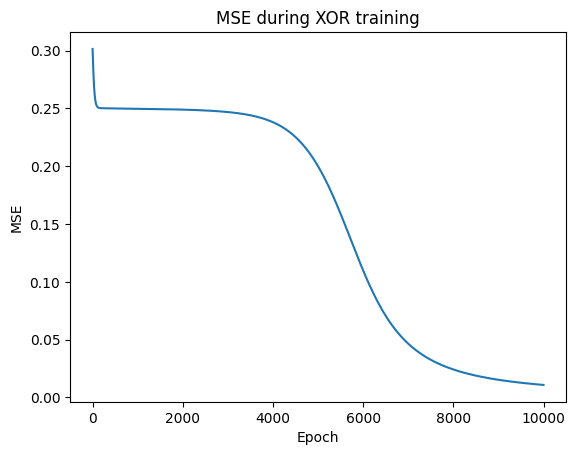

In [72]:
plt.plot(mse_history)
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("MSE during XOR training")
plt.show()

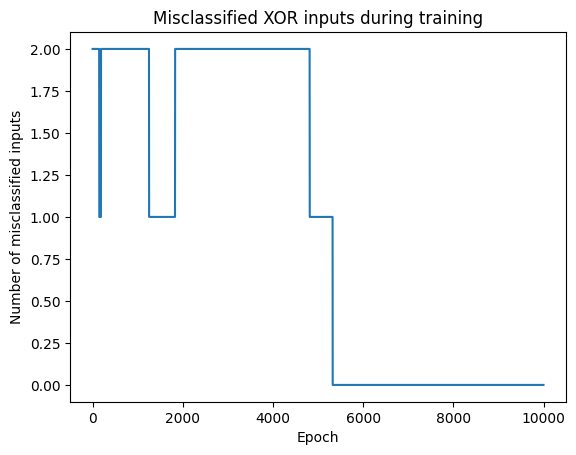

In [73]:
plt.plot(misclassified_history)
plt.xlabel("Epoch")
plt.ylabel("Number of misclassified inputs")
plt.title("Misclassified XOR inputs during training")
plt.show()

In [74]:
predictions = get_predictions(XOR_data_in)

predicted_labels = (
    predictions >= 0.5
).astype(int)

print("Input       Prediction      Class      Target")

for x, prediction, predicted, target in zip(
    XOR_data_in,
    predictions,
    predicted_labels,
    XOR_label
):

    print(
        x,
        "   ",
        f"{prediction:.4f}",
        "       ",
        predicted,
        "         ",
        target
    )

Input       Prediction      Class      Target
[0 0]     0.1058         0           0
[0 1]     0.9051         1           1
[1 0]     0.8793         1           1
[1 1]     0.0913         0           0


In [75]:
final_mse = mse(
    predictions,
    XOR_label
)

misclassified = np.sum(
    predicted_labels != XOR_label
)

print("\nFinal MSE:", final_mse)
print("Misclassified:", misclassified)


Final MSE: 0.010777710940759341
Misclassified: 0


Different learning rates

Epoch     0 | MSE = 0.353676 | Errors = 2
Epoch  1000 | MSE = 0.341169 | Errors = 2
Epoch  2000 | MSE = 0.328529 | Errors = 2
Epoch  3000 | MSE = 0.316147 | Errors = 2
Epoch  4000 | MSE = 0.304423 | Errors = 2
Epoch  5000 | MSE = 0.293706 | Errors = 2
Epoch  6000 | MSE = 0.284244 | Errors = 2
Epoch  7000 | MSE = 0.276156 | Errors = 2
Epoch  8000 | MSE = 0.269436 | Errors = 2
Epoch  9000 | MSE = 0.263985 | Errors = 2
Epoch     0 | MSE = 0.320325 | Errors = 2
Epoch  1000 | MSE = 0.253296 | Errors = 1
Epoch  2000 | MSE = 0.250744 | Errors = 2
Epoch  3000 | MSE = 0.250249 | Errors = 2
Epoch  4000 | MSE = 0.249849 | Errors = 2
Epoch  5000 | MSE = 0.249493 | Errors = 1
Epoch  6000 | MSE = 0.249165 | Errors = 1
Epoch  7000 | MSE = 0.248855 | Errors = 1
Epoch  8000 | MSE = 0.248553 | Errors = 1
Epoch  9000 | MSE = 0.248249 | Errors = 1
Epoch     0 | MSE = 0.256206 | Errors = 2
Epoch  1000 | MSE = 0.224404 | Errors = 1
Epoch  2000 | MSE = 0.204159 | Errors = 1
Epoch  3000 | MSE = 0.189993 | Err

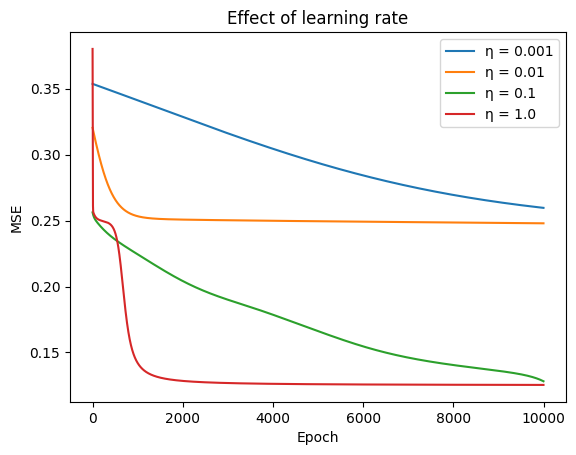

η = 0.001 | Final MSE = 0.259648 | Misclassified = 2
η = 0.01 | Final MSE = 0.247938 | Misclassified = 1
η = 0.1 | Final MSE = 0.128167 | Misclassified = 1
η = 1.0 | Final MSE = 0.125400 | Misclassified = 2


In [79]:
learning_rates = [0.001,0.01,0.1,1.0]
learning_rate_results = {}

for lr in learning_rates:
    initialize_weights()
    mse_history, misclassified_history = train(
        XOR_data_in,
        XOR_label,
        learning_rate=lr,
        epochs=10000,
        print_every=1000
    )
    learning_rate_results[lr] = {
        "mse": mse_history,
        "misclassified": misclassified_history
    }

for lr in learning_rates:
    plt.plot( learning_rate_results[lr]["mse"], label=f"η = {lr}" )
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Effect of learning rate")
plt.legend()
plt.show()

for lr in learning_rates:
    final_mse = (learning_rate_results[lr]["mse"][-1])
    final_misclassified = (learning_rate_results[lr]["misclassified"][-1])
    print(
        f"η = {lr} | "
        f"Final MSE = {final_mse:.6f} | "
        f"Misclassified = {final_misclassified}"
    )